In [1]:
pip install pandas matplotlib seaborn numpy

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [6]:
df = pd.read_csv("C:\\Users\\Administrator\\Downloads\\Code Alpha\\Data Analyst Intern\\titanic.csv")
print("✅ Dataset loaded!")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

✅ Dataset loaded!
Rows: 891, Columns: 12


In [7]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage (%)": missing_percent
})

missing_df[missing_df["Missing Values"] > 0]

,Missing Values,Percentage (%)
Age,177,19.865320
Cabin,687,77.104377
Embarked,2,0.224467


In [11]:
# Q1: Overall survival rate
survival_rate = df['Survived'].mean() * 100
print(f"Overall Survival Rate: {survival_rate:.2f}%")

# Q2: Survival by gender
print("\nSurvival Rate by Gender (%):")
print(df.groupby('Sex')['Survived'].mean() * 100)

# Q3: Survival by class
print("\nSurvival Rate by Class (%):")
print(df.groupby('Pclass')['Survived'].mean() * 100)

# Q4: Average age
print("\nAverage Age (0=Did not survive, 1=Survived):")
print(df.groupby('Survived')['Age'].mean())

Overall Survival Rate: 38.38%

Survival Rate by Gender (%):
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

Survival Rate by Class (%):
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

Average Age (0=Did not survive, 1=Survived):
Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64


C:\Users\Administrator\AppData\Local\Temp\ipykernel_23616\2614901020.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='Set2')


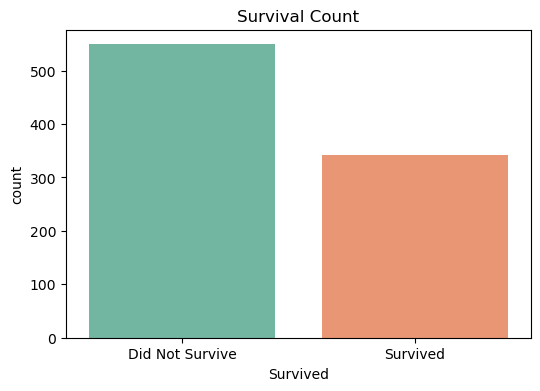

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df, palette='Set2')
plt.title("Survival Count")
plt.xticks([0, 1], ['Did Not Survive', 'Survived'])
plt.savefig("plot1_survival_count.png", dpi=150)
plt.show()

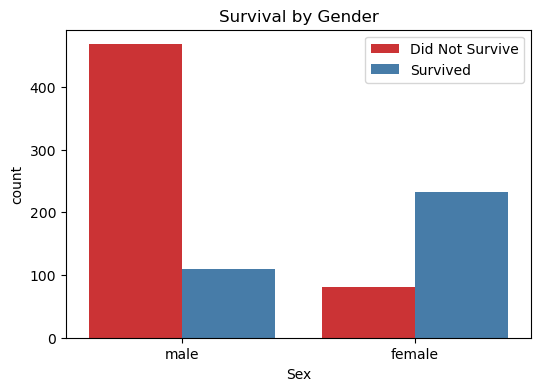

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=df, palette='Set1')
plt.title("Survival by Gender")
plt.legend(['Did Not Survive', 'Survived'])
plt.savefig("plot2_survival_gender.png", dpi=150)
plt.show()

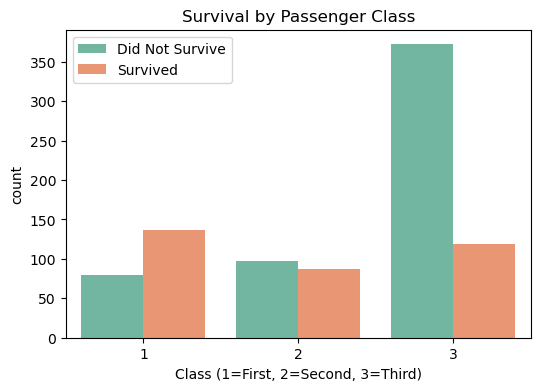

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', hue='Survived', data=df, palette='Set2')
plt.title("Survival by Passenger Class")
plt.xlabel("Class (1=First, 2=Second, 3=Third)")
plt.legend(['Did Not Survive', 'Survived'])
plt.savefig("plot3_survival_class.png", dpi=150)
plt.show()

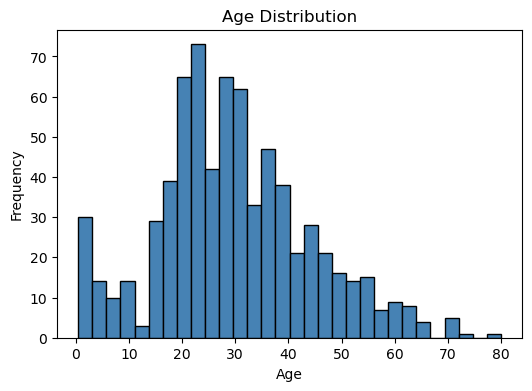

In [15]:
plt.figure(figsize=(6,4))
df['Age'].dropna().plot(kind='hist', bins=30, color='steelblue', edgecolor='black')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.savefig("plot4_age_distribution.png", dpi=150)
plt.show()

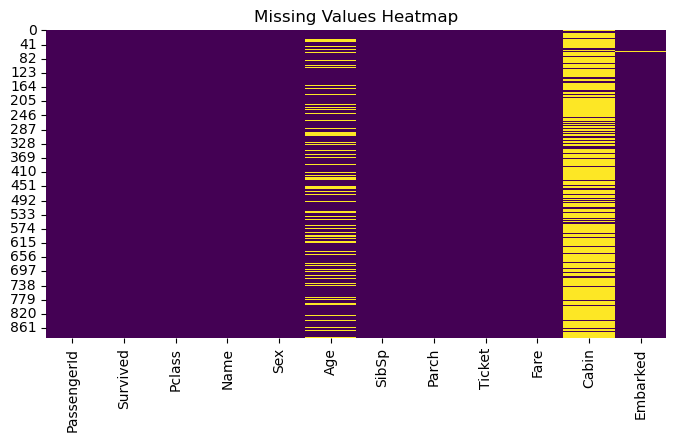

In [16]:
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.savefig("plot5_missing_values.png", dpi=150)
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_23616\1389112346.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass', y='Fare', data=df, palette='pastel')


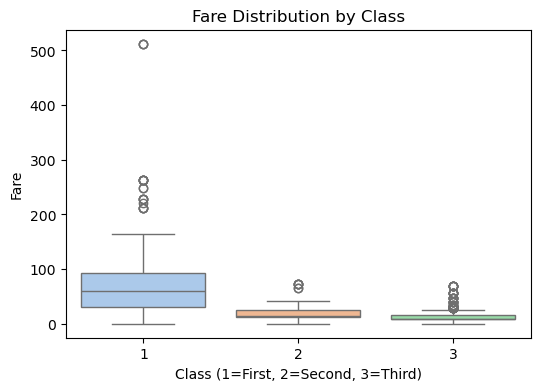

In [17]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Pclass', y='Fare', data=df, palette='pastel')
plt.title("Fare Distribution by Class")
plt.xlabel("Class (1=First, 2=Second, 3=Third)")
plt.savefig("plot6_fare_class.png", dpi=150)
plt.show()

In [18]:
print("=" * 45)
print("       📊 KEY FINDINGS — TITANIC EDA")
print("=" * 45)
print(f"✅ Total Passengers  : {len(df)}")
print(f"✅ Survived          : {df['Survived'].sum()}")
print(f"✅ Survival Rate     : {df['Survived'].mean()*100:.2f}%")
print(f"✅ Female Survival   : {df[df['Sex']=='female']['Survived'].mean()*100:.2f}%")
print(f"✅ Male Survival     : {df[df['Sex']=='male']['Survived'].mean()*100:.2f}%")
print(f"✅ 1st Class Survival: {df[df['Pclass']==1]['Survived'].mean()*100:.2f}%")
print(f"✅ 3rd Class Survival: {df[df['Pclass']==3]['Survived'].mean()*100:.2f}%")
print(f"✅ Avg Age (Survived): {df[df['Survived']==1]['Age'].mean():.1f} years")
print(f"✅ Avg Age (Not Sur.): {df[df['Survived']==0]['Age'].mean():.1f} years")
print("=" * 45)

       📊 KEY FINDINGS — TITANIC EDA
✅ Total Passengers  : 891
✅ Survived          : 342
✅ Survival Rate     : 38.38%
✅ Female Survival   : 74.20%
✅ Male Survival     : 18.89%
✅ 1st Class Survival: 62.96%
✅ 3rd Class Survival: 24.24%
✅ Avg Age (Survived): 28.3 years
✅ Avg Age (Not Sur.): 30.6 years


In [1]:
from IPython.display import Image
Image("titanic_eda.png")

FileNotFoundError: No such file or directory: 'titanic_eda.png'

FileNotFoundError: No such file or directory: 'titanic_eda.png'

<IPython.core.display.Image object>